In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

PATH_MACRO  = Path(r"C:\Users\kelvi\Downloads\macro_merged_monthly_with_z.csv")   
PATH_SECTOR = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Americas CS Country.xlsx")

TRAIN_START, TRAIN_END = pd.Period('1985-01','M'), pd.Period('2018-12','M')
OOS_START,   OOS_END   = pd.Period('2019-01','M'), pd.Period('2024-12','M')

NEW_STATE_MAP = {
    "usd_trade_weighted_broad_z_wins":  "USD broad",
    "breakeven_inflation_10y_z_wins":   "Breakeven 10y",
    "high_yield_oas_z_wins":            "HY OAS",
    "umich_consumer_sentiment_z_wins":  "UMich",
    "real_yield_10y_z_wins":            "Real 10y",
}

def ann_sr(x: np.ndarray, daily=True) -> float:
    """Annualized Sharpe ratio on a 1D array of returns."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    mu, sig = x.mean(), x.std()
    if sig == 0:
        return 0.0
    scale = 252 if daily else 12
    return (mu / sig) * np.sqrt(scale)


In [10]:
def _to_period_m_from_col(df: pd.DataFrame, col: str) -> pd.DataFrame:
    per = pd.to_datetime(df[col], errors="coerce").dt.to_period("M")
    out = df.copy()
    out[col] = per
    out = out.dropna(subset=[col]).set_index(col).sort_index()
    return out

def prep_inputs(PATH_SECTOR: Path, macro_z: pd.DataFrame):
    sec = pd.read_excel(PATH_SECTOR)
    if "Dates" not in sec.columns:
        raise ValueError("Expected a 'Dates' column in the sector file.")
    sec["Dates"] = pd.to_datetime(sec["Dates"], errors="coerce")
    sec = sec.dropna(subset=["Dates"]).sort_values("Dates").set_index("Dates")

    assets = [c for c in sec.columns if c != "Dates" and pd.api.types.is_numeric_dtype(sec[c])]
    if not assets:
        raise ValueError("No numeric sector columns found. Check your sector file.")
    sec_ret_daily   = sec[assets].pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all")
    sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    sector_months = sec_ret_monthly.index.sort_values()

    if "Month" in macro_z.columns:
        Z = _to_period_m_from_col(macro_z, "Month")
    else:
        raise ValueError("macro_z must contain a 'Month' column (period or parseable).")

    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro state columns in macro_z.")
    Z = Z[macro_cols].astype(float)

    full_grid = pd.period_range(Z.index.min(), Z.index.max(), freq="M")
    Z = Z.reindex(full_grid).ffill()
    Z = Z.reindex(sector_months).ffill()

    # Sanity prints
    print("=== STEP 1 — Data loaded & aligned ===")
    print(f"Sectors daily: {sec_ret_daily.shape}, monthly: {sec_ret_monthly.shape}, assets: {len(assets)}")
    print(f"Macro states matrix Z: {Z.shape} [rows=months, cols=features]")
    print(f"Time range — sectors monthly: {sector_months.min()} .. {sector_months.max()}")
    return sec_ret_daily, sec_ret_monthly, sector_months, assets, Z

macro_z = pd.read_csv(PATH_MACRO)
if "Month" not in macro_z.columns:
    if "date" in macro_z.columns:
        macro_z["Month"] = pd.to_datetime(macro_z["date"], errors="coerce").dt.to_period("M")
    else:
        raise ValueError("Need a 'Month' or 'date' column in macro CSV.")

rename_cols = {k:v for k,v in NEW_STATE_MAP.items() if k in macro_z.columns}
macro_z = macro_z.rename(columns=rename_cols)

sec_ret_daily, sec_ret_monthly, sector_months, assets, features_all = prep_inputs(PATH_SECTOR, macro_z)


=== STEP 1 — Data loaded & aligned ===
Sectors daily: (24946, 69), monthly: (1148, 69), assets: 69
Macro states matrix Z: (1148, 15) [rows=months, cols=features]
Time range — sectors monthly: 1930-01 .. 2025-08


In [11]:
PATH_BASELINE = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

df_old = pd.read_excel(PATH_BASELINE)
df_old["Month"] = pd.to_datetime(df_old["Month"], errors="coerce").dt.to_period("M")
df_old = df_old.set_index("Month").sort_index()

macro_z["Month"] = pd.to_datetime(macro_z["Month"], errors="coerce").dt.to_period("M")
macro_z = macro_z.set_index("Month").sort_index()

new_vars = list(NEW_STATE_MAP.values())
df_new  = macro_z[new_vars]

features_all = df_old.merge(df_new, left_index=True, right_index=True, how="inner")

print("=== STEP 1B — Feature set merged ===")
print(f"Baseline cols: {df_old.shape[1]} | New cols: {len(new_vars)} | Total: {features_all.shape[1]}")
print("New vars present:", new_vars)


=== STEP 1B — Feature set merged ===
Baseline cols: 7 | New cols: 5 | Total: 12
New vars present: ['USD broad', 'Breakeven 10y', 'HY OAS', 'UMich', 'Real 10y']


In [12]:
def rank_similar_months_euclid_fixed(F_full, F_train, cur_per):
    """Return ALL past training months ranked by Euclidean distance to cur_per."""
    if cur_per not in F_full.index:
        return []
    Xtr = F_train.loc[F_train.index < cur_per].dropna(how="any")
    if Xtr.shape[0] == 0:
        return []
    x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
    common_cols = Xtr.columns.intersection(x0.columns)
    if common_cols.empty:
        return []
    Xm = Xtr[common_cols].values.astype(float)
    x0v = x0.iloc[0][common_cols].values.astype(float)
    d = np.linalg.norm(Xm - x0v[None,:], axis=1)
    order = np.argsort(d)
    return Xtr.index[order].tolist()

def make_quintile_buckets(ranked_months):
    """Mirror your quintile_members_euclid_fixed: 20%–20% split."""
    buckets = {q: [] for q in range(1,6)}
    if not ranked_months:
        return buckets
    n = len(ranked_months)
    k20 = max(int(0.2 * n), 1)
    q1 = ranked_months[:k20]         
    q5 = ranked_months[-k20:]        
    mid = ranked_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(mid, 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1), 2:list(q2), 3:list(q3), 4:list(q4), 5:list(q5)}


def smoke_test_neighbors(F_all, F_train, months_bt, show=3):
    print("\n=== STEP 2 — Smoke test neighbors/buckets ===")
    for cur_per in months_bt[:min(len(months_bt)-1, show)]:
        neigh = rank_similar_months_euclid_fixed(F_all, F_train, cur_per)  
        buckets = make_quintile_buckets(neigh)
        print(f"{cur_per}: neighbors={len(neigh)} | bucket sizes={[len(buckets[q]) for q in range(1,6)]}")



In [13]:
def run_backtest_sr(
    F_full: pd.DataFrame,
    F_train: pd.DataFrame,
    months_bt: list,
    sec_ret_daily: pd.DataFrame,
    sec_ret_monthly: pd.DataFrame,
    assets: list
) -> dict:


    def make_quintile_buckets(ranked_months):
        """Split into Q1=closest 20%, Q5=farthest 20%, Q2–Q4=middle thirds."""
        buckets = {q: [] for q in range(1, 6)}
        if not ranked_months:
            return buckets
        n = len(ranked_months)
        k20 = max(int(0.2 * n), 1)
        q1 = ranked_months[:k20]
        q5 = ranked_months[-k20:]
        mid = ranked_months[k20:-k20]
        if len(mid) >= 3:
            q2, q3, q4 = np.array_split(mid, 3)
        else:
            q2, q3, q4 = [], mid, []
        return {1: list(q1), 2: list(q2), 3: list(q3), 4: list(q4), 5: list(q5)}

    def rank_similar_months_euclid_fixed(F_full, F_train, cur_per):
        if cur_per not in F_full.index:
            return []
        Xtr = F_train.dropna(how="any")
        if Xtr.empty:
            return []
        x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
        common_cols = Xtr.columns.intersection(x0.columns)
        if common_cols.empty:
            return []
        Xm = Xtr[common_cols].values.astype(float)
        x0v = x0.iloc[0][common_cols].values.astype(float)
        d = np.linalg.norm(Xm - x0v[None, :], axis=1)
        order = np.argsort(d)
        return Xtr.index[order].tolist()

    def ann_sr(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return 0.0
        mu, sig = x.mean(), x.std()
        if sig == 0:
            return 0.0
        return (mu / sig) * np.sqrt(252)

    def ann_ret(x: pd.Series) -> float:
        n = len(x)
        return (1 + x).prod()**(252.0/n) - 1 if n > 0 else np.nan

    def ann_vol(x: pd.Series) -> float:
        return x.std() * np.sqrt(252)

    def max_dd(x: pd.Series) -> float:
        eq = (1+x).cumprod()
        return (eq/eq.cummax() - 1).min()

    ret_pairs_by_q = {q: [] for q in range(1, 6)}

    for i in range(len(months_bt) - 1):
        cur_per, nxt_per = months_bt[i], months_bt[i+1]

        ranked = rank_similar_months_euclid_fixed(F_full, F_train, cur_per)
        if not ranked:
            continue
        buckets = make_quintile_buckets(ranked)

        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt_per]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1, 2, 3, 4, 5]:
            months_sim = buckets[q]
            if len(months_sim) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = pd.PeriodIndex(months_sim, freq="M") + 1
                signs = {}
                idx_inter = sec_ret_monthly.index.intersection(idx_sim_next)
                for a in assets:
                    r = sec_ret_monthly.loc[idx_inter, a]
                    signs[a] = np.sign(r.mean()) if not r.empty else 0
                w = pd.Series(signs, index=assets, dtype=float)
                q_daily = (Rm * w).mean(axis=1)
            ret_pairs_by_q[q].extend(list(q_daily.items()))

    q_series = {q: pd.Series(dict(ret_pairs_by_q[q])).sort_index() for q in range(1, 6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        common_idx = q_series[q].index if common_idx is None else common_idx.intersection(q_series[q].index)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).dropna()

    ports = {f"Q{q}": q_series[q] for q in range(1,6)}
    ls_tmp = pd.concat([ports['Q1'], ports['Q5']], axis=1).dropna()
    ports["LS (Q1-Q5)"] = (ls_tmp.iloc[:,0] - ls_tmp.iloc[:,1])
    ports["Long-only"]  = long_only

    rows = {}
    for name, s in ports.items():
        rows[name] = {
            "Ann. Return": ann_ret(s),
            "Ann. Vol": ann_vol(s),
            "Ann. Sharpe": ann_sr(s),
            "Max DD": max_dd(s),
            "N days": len(s),
        }
    summary_df = pd.DataFrame(rows).T

    return {
        "Q1_SR": summary_df.loc["Q1", "Ann. Sharpe"],
        "Q5_SR": summary_df.loc["Q5", "Ann. Sharpe"],
        "ports": ports,         
        "summary": summary_df   
    }



=== STEP 4 — Feature sets ===
Total macro cols: 12 | Baseline cols: 7 | New vars present: ['USD broad', 'Breakeven 10y', 'HY OAS', 'UMich', 'Real 10y']

=== STEP 2 — Smoke test neighbors/buckets ===
2019-01: neighbors=146 | bucket sizes=[29, 30, 29, 29, 29]
2019-02: neighbors=146 | bucket sizes=[29, 30, 29, 29, 29]
2019-03: neighbors=0 | bucket sizes=[0, 0, 0, 0, 0]

Baseline Sharpe Ratios -> Q1: 0.805, Q5: 0.776


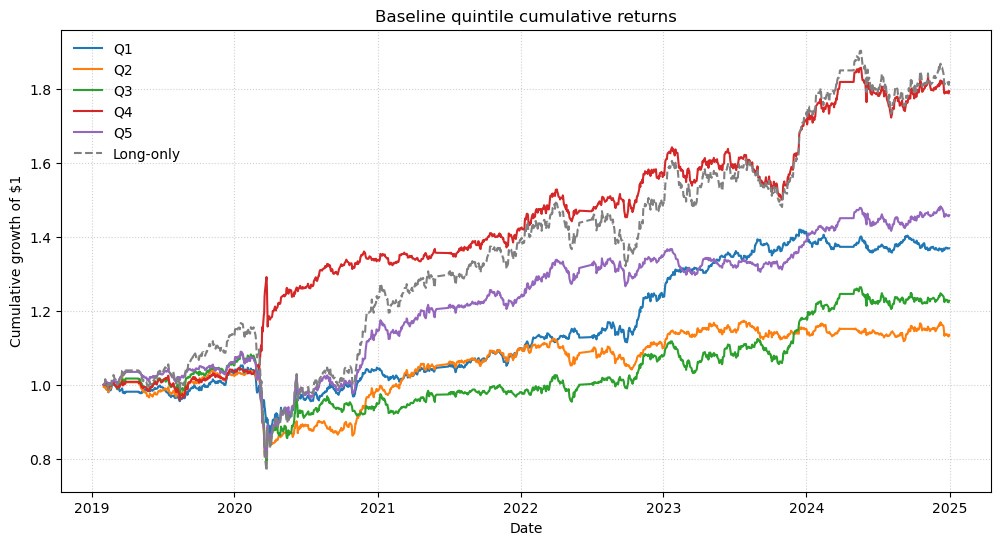

In [14]:
all_macro_cols = [c for c in features_all.columns if pd.api.types.is_numeric_dtype(features_all[c])]
candidate_vars = [v for v in NEW_STATE_MAP.values() if v in all_macro_cols]  # present new ones
baseline_cols  = [c for c in all_macro_cols if c not in candidate_vars]      # everything else

print("\n=== STEP 4 — Feature sets ===")
print(f"Total macro cols: {len(all_macro_cols)} | Baseline cols: {len(baseline_cols)} | New vars present: {candidate_vars}")

if len(baseline_cols) == 0:
    raise ValueError("Baseline feature set is empty. Add your core baseline features to avoid trivial zeros.")

oos_stop  = min(OOS_END, sector_months.max())
months_bt = sector_months[(sector_months >= OOS_START) & (sector_months <= oos_stop)]
if len(months_bt) < 2:
    raise ValueError(f"No OOS months. sector range {sector_months.min()}..{sector_months.max()}, requested {OOS_START}..{OOS_END}")

F_all_base   = features_all[baseline_cols].copy()
F_train_base = F_all_base.loc[(F_all_base.index >= TRAIN_START) & (F_all_base.index <= TRAIN_END)].dropna(how='any')
if F_train_base.empty:
    raise ValueError("F_train_base is empty after NA drop. Check training window and missing values.")

smoke_test_neighbors(F_all_base, F_train_base, months_bt, show=3)

baseline_res = run_backtest_sr(F_all_base, F_train_base, months_bt,
                               sec_ret_daily, sec_ret_monthly, assets)


SR_Q1_base, SR_Q5_base = baseline_res["Q1_SR"], baseline_res["Q5_SR"]
print(f"\nBaseline Sharpe Ratios -> Q1: {SR_Q1_base:.3f}, Q5: {SR_Q5_base:.3f}")
import matplotlib.pyplot as plt

def plot_cum_returns(port_returns: dict, title="Cumulative Returns by Quintile"):

    plt.figure(figsize=(12,6))
    for q in [1,2,3,4,5]:
        if f"Q{q}" not in port_returns: 
            continue
        s = port_returns[f"Q{q}"]
        cum = (1+s).cumprod()
        plt.plot(cum.index, cum, label=f"Q{q}")
    
    if "Long-only" in port_returns:
        plt.plot((1+port_returns["Long-only"]).cumprod(), 
                 color="gray", ls="--", label="Long-only")
    if "LS (Q1−Q5)" in port_returns:
        plt.plot((1+port_returns["LS (Q1−Q5)"]).cumprod(), 
                 color="black", lw=1.2, label="LS (Q1−Q5)")
    
    plt.title(title)
    plt.xlabel("Date"); plt.ylabel("Cumulative growth of $1")
    plt.legend(frameon=False)
    plt.grid(ls=":", alpha=0.6)
    plt.show()

plot_cum_returns(baseline_res["ports"], title="Baseline quintile cumulative returns")



In [16]:
rows = []
for var in candidate_vars:
    cols = baseline_cols + [var]
    F_all_var   = features_all[cols].copy()
    F_train_var = F_all_var.loc[(F_all_var.index >= TRAIN_START) & (F_all_var.index <= TRAIN_END)].dropna(how='any')
    if F_train_var.empty:
        print(f"[WARN] Training set empty for {var} (after NA drop) — skipping.")
        continue

    res_var = run_backtest_sr(F_all_var, F_train_var, months_bt, 
                              sec_ret_daily, sec_ret_monthly, assets)

    SR_Q1_new, SR_Q5_new = res_var["Q1_SR"], res_var["Q5_SR"]

    spread_base = SR_Q1_base - SR_Q5_base
    spread_new  = SR_Q1_new - SR_Q5_new

    improves = spread_new > spread_base

    rows.append({
        "Variable": var,
        "SR_Q1_base": SR_Q1_base,
        "SR_Q5_base": SR_Q5_base,
        "SR_Q1_new": SR_Q1_new,
        "SR_Q5_new": SR_Q5_new,
        "Improves monotonicity?": improves
    })

results_df = pd.DataFrame(rows)
print("\n=== RESULTS ===")
print(results_df.to_string(index=False))



=== RESULTS ===
     Variable  SR_Q1_base  SR_Q5_base  SR_Q1_new  SR_Q5_new  Spread_base (Q1-Q5)  Spread_new (Q1-Q5)  Improves monotonicity?
    USD broad    0.805179    0.776058   1.736698   1.064137             0.029121            0.672561                    True
Breakeven 10y    0.805179    0.776058   1.380027   1.023963             0.029121            0.356064                    True
       HY OAS    0.805179    0.776058   1.180950   1.452007             0.029121           -0.271057                   False
        UMich    0.805179    0.776058   1.112741   1.098748             0.029121            0.013992                   False
     Real 10y    0.805179    0.776058   0.866574   1.162774             0.029121           -0.296199                   False



=== RESULTS (Baseline + each NEW var from CSV) ===
     Variable  SR_Q1_base  SR_Q5_base  SR_Q1_new  SR_Q5_new  Spread_base(Q1-Q5)  Spread_new(Q1-Q5)  Improves monotonicity?
     Real 10y       0.287      -0.296      0.432     -0.139               0.583              0.571                   False
        UMich       0.287      -0.296      0.250     -0.013               0.583              0.263                   False
    USD broad       0.287      -0.296      0.311      0.057               0.583              0.254                   False
Breakeven 10y       0.287      -0.296      0.598      0.402               0.583              0.196                   False
       HY OAS       0.287      -0.296      0.351      0.350               0.583              0.001                   False


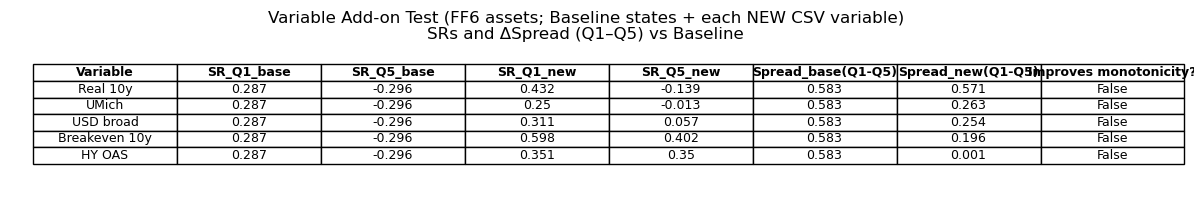

In [22]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path


PATH_FACTORS = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx")
PATH_BASELINE = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")
PATH_MACROCSV = Path(r"C:\Users\kelvi\Downloads\macro_merged_monthly_with_z.csv")  
NEW_STATE_MAP = {
    "usd_trade_weighted_broad_z_wins":  "USD broad",
    "breakeven_inflation_10y_z_wins":   "Breakeven 10y",
    "high_yield_oas_z_wins":            "HY OAS",
    "umich_consumer_sentiment_z_wins":  "UMich",
    "real_yield_10y_z_wins":            "Real 10y",
}


ff = pd.read_excel(PATH_FACTORS)
date_col = next((c for c in ["Date","Dates","DATE","date","dt"] if c in ff.columns), None)
if date_col is None:
    raise ValueError("Could not find a date column in the FF6 file.")
ff[date_col] = pd.to_datetime(ff[date_col], errors="coerce")
ff = ff.dropna(subset=[date_col]).set_index(date_col).sort_index()

std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
present  = [c for c in std_cols if c in ff.columns]
if len(present) == 0:
    raise ValueError("FF6 columns not found in the factor file.")

ff[present] = ff[present].astype(float) / 100.0

assets = [c for c in present if c != "RF"]

sec_ret_daily = (
    ff[assets]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(how="all")
    .clip(-0.8, 0.8)  
)
sec_ret_monthly = (1 + sec_ret_daily).resample("ME").prod() - 1.0
sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
sector_months = sec_ret_monthly.index


df_old = pd.read_excel(PATH_BASELINE)
if "Month" not in df_old.columns:
    for cand in ["month","MONTH","Date","Dates"]:
        if cand in df_old.columns:
            df_old = df_old.rename(columns={cand: "Month"})
            break
if "Month" not in df_old.columns:
    raise ValueError("Baseline macro file must contain a 'Month' column.")

df_old["Month"] = pd.to_datetime(df_old["Month"], errors="coerce").dt.to_period("M")
df_old = df_old.set_index("Month").sort_index()

old_numeric = [c for c in df_old.columns if pd.api.types.is_numeric_dtype(df_old[c])]
df_old = df_old[old_numeric].astype(float)


macro_csv = pd.read_csv(PATH_MACROCSV)
if "Month" not in macro_csv.columns:
    if "date" in macro_csv.columns:
        macro_csv["Month"] = pd.to_datetime(macro_csv["date"], errors="coerce").dt.to_period("M")
    else:
        raise ValueError("macro CSV needs 'Month' or 'date' column.")
macro_csv = macro_csv.rename(columns={k:v for k,v in NEW_STATE_MAP.items() if k in macro_csv.columns})
macro_csv["Month"] = pd.to_datetime(macro_csv["Month"], errors="coerce").dt.to_period("M")
macro_csv = macro_csv.set_index("Month").sort_index()

candidate_vars = [v for v in NEW_STATE_MAP.values() if v in macro_csv.columns]
if not candidate_vars:
    raise ValueError("None of the NEW_STATE_MAP variables were found in the CSV.")

df_new = macro_csv[candidate_vars].astype(float)

features_all = df_old.merge(df_new, left_index=True, right_index=True, how="inner")

features_all = features_all.reindex(sector_months)

baseline_cols = [c for c in df_old.columns if c in features_all.columns]
if not baseline_cols:
    raise ValueError("Baseline feature set is empty after merging. Check overlap between baseline states and CSV months.")

TRAIN_START, TRAIN_END = pd.Period("2006-06","M"), pd.Period("2018-12","M")
OOS_START,   OOS_END   = pd.Period("2019-01","M"), pd.Period("2024-12","M")

oos_stop  = min(OOS_END, sector_months.max())
months_bt = sector_months[(sector_months >= OOS_START) & (sector_months <= oos_stop)]

F_all_base   = features_all[baseline_cols]
F_train_base = F_all_base.loc[(F_all_base.index >= TRAIN_START) & (F_all_base.index <= TRAIN_END)].dropna(how="any")
if F_train_base.empty:
    raise ValueError("Baseline training set is empty after NA drop. Adjust TRAIN_START/END or check macro data overlap.")


def run_backtest_sr(F_all: pd.DataFrame, F_train: pd.DataFrame, months_bt, 
                    sec_ret_daily: pd.DataFrame, sec_ret_monthly: pd.DataFrame, assets: list):
    def rank_similar(F_full, F_train, cur_per):
        if cur_per not in F_full.index: return []
        x0 = F_full.loc[[cur_per]].dropna(axis=1)
        if x0.empty: return []
        Xtr = F_train.dropna(how="any")
        common = Xtr.columns.intersection(x0.columns)
        if common.empty or Xtr.empty: return []
        X = Xtr[common].values.astype(float)
        x = x0.iloc[0][common].values.astype(float)
        d = np.linalg.norm(X - x[None, :], axis=1)
        return Xtr.index[np.argsort(d)].tolist()

    def make_quintiles(ranked):
        n = len(ranked); k20 = max(int(0.2*n), 1)
        q1, q5 = ranked[:k20], ranked[-k20:]
        mid = ranked[k20:-k20]
        if len(mid) >= 3: q2, q3, q4 = np.array_split(np.array(mid), 3)
        else: q2, q3, q4 = [], mid, []
        return {1:list(q1), 2:list(q2), 3:list(q3), 4:list(q4), 5:list(q5)}

    def ann_sr(x):
        x = pd.Series(x).dropna()
        if x.empty: return 0.0
        s = x.std()
        return (x.mean()/s)*np.sqrt(252) if s != 0 else 0.0

    months_bt = list(months_bt)
    returns_by_q = {q: [] for q in range(1,6)}

    for i in range(len(months_bt)-1):
        cur, nxt = months_bt[i], months_bt[i+1]
        ranked = rank_similar(F_all, F_train, cur)
        if not ranked: continue
        buckets = make_quintiles(ranked)

        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt]
        if len(dts) == 0: continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in range(1,6):
            idx_sim = pd.PeriodIndex(buckets[q], freq="M") + 1
            idx_inter = sec_ret_monthly.index.intersection(idx_sim)
            signs = {}
            for a in assets:
                r = sec_ret_monthly.loc[idx_inter, a]
                signs[a] = np.sign(r.mean()) if not r.empty else 0
            w = pd.Series(signs, index=assets, dtype=float)
            q_daily = (Rm * w).mean(axis=1)
            returns_by_q[q].extend(list(q_daily.values))

    q_series = {q: pd.Series(returns_by_q[q]) for q in range(1,6)}
    min_len = min(len(s) for s in q_series.values() if len(s) > 0)
    for q in q_series:
        q_series[q] = q_series[q].iloc[:min_len]

    return {"Q1_SR": float(ann_sr(q_series[1])), "Q5_SR": float(ann_sr(q_series[5]))}

base_res = run_backtest_sr(F_all_base, F_train_base, months_bt, sec_ret_daily, sec_ret_monthly, assets)
SR_Q1_base, SR_Q5_base = base_res["Q1_SR"], base_res["Q5_SR"]
spread_base = SR_Q1_base - SR_Q5_base


rows = []
for var in candidate_vars:
    cols = baseline_cols + [var]
    F_all_var   = features_all[cols].copy()
    F_train_var = F_all_var.loc[(F_all_var.index >= TRAIN_START) & (F_all_var.index <= TRAIN_END)].dropna(how="any")
    if F_train_var.empty:
        rows.append({"Variable": var, "Note": "Skipped (empty training after NA drop)"})
        continue

    res_var = run_backtest_sr(F_all_var, F_train_var, months_bt, sec_ret_daily, sec_ret_monthly, assets)
    SR_Q1_new, SR_Q5_new = res_var["Q1_SR"], res_var["Q5_SR"]
    spread_new  = SR_Q1_new - SR_Q5_new
    improves    = spread_new > spread_base

    rows.append({
        "Variable": var,
        "SR_Q1_base": round(SR_Q1_base, 3),
        "SR_Q5_base": round(SR_Q5_base, 3),
        "SR_Q1_new": round(SR_Q1_new, 3),
        "SR_Q5_new": round(SR_Q5_new, 3),
        "Spread_base(Q1-Q5)": round(spread_base, 3),
        "Spread_new(Q1-Q5)": round(spread_new, 3),
        "Improves monotonicity?": improves
    })

results_df = pd.DataFrame(rows)
if "Spread_new(Q1-Q5)" in results_df.columns:
    results_df = results_df.sort_values("Spread_new(Q1-Q5)", ascending=False)

print("\n=== RESULTS (Baseline + each NEW var from CSV) ===")
print(results_df.to_string(index=False))


fig, ax = plt.subplots(figsize=(12, 0.5 + 0.35*max(4, len(results_df))))
ax.axis('off')

tbl = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='upper left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.title("Variable Add-on Test (FF6 assets; Baseline states + each NEW CSV variable)\nSRs and ΔSpread (Q1–Q5) vs Baseline", pad=16)
plt.tight_layout()
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\576338214.py:61: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sec_ret_monthly = (1 + sec_ret_daily).resample("M").prod() - 1


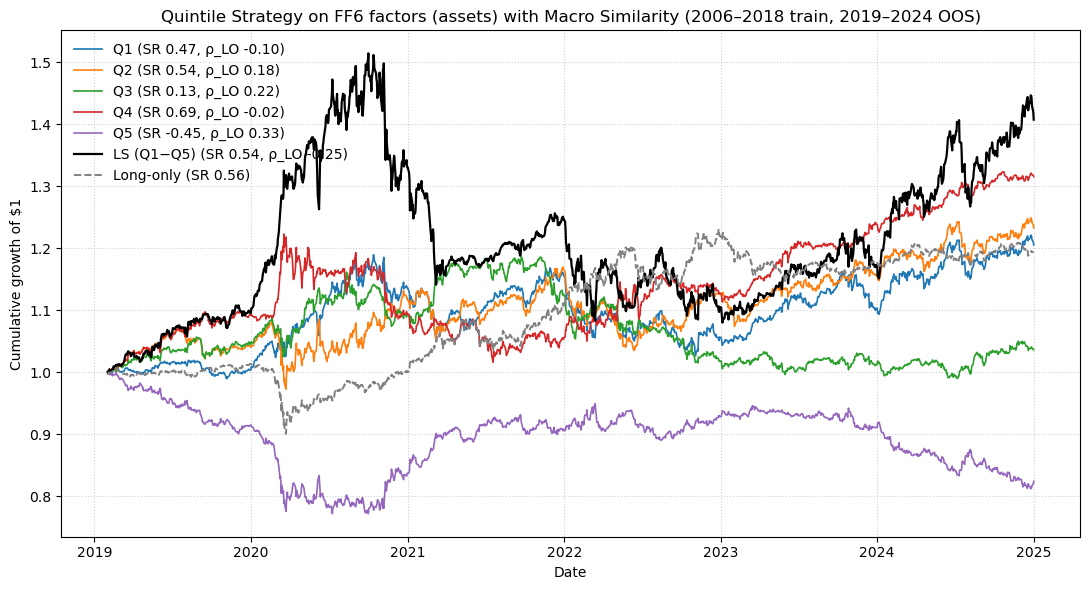

In [17]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

def safe_cumprod(r: pd.Series) -> pd.Series:
    s = (1 + r).astype(float).clip(lower=1e-6, upper=1e6)
    cp = s.cumprod().replace([np.inf, -np.inf], np.nan).ffill().fillna(1.0)
    return cp

def ann_sr(s: pd.Series):
    s = s.dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series):
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def rank_similar(F_full: pd.DataFrame, F_train: pd.DataFrame, cur_per: pd.Period):
    if cur_per not in F_full.index:
        return []
    x0 = F_full.loc[[cur_per]].dropna(axis=1)
    if x0.empty: return []
    Xtr = F_train.dropna(how="any")
    common = Xtr.columns.intersection(x0.columns)
    if common.empty or Xtr.empty: return []
    X = Xtr[common].values.astype(float)
    x = x0.iloc[0][common].values.astype(float)
    d = np.linalg.norm(X - x[None, :], axis=1)
    return Xtr.index[np.argsort(d)].tolist()

def make_quintiles(ranked):
    n = len(ranked); k20 = max(int(0.2 * n), 1)
    q1, q5 = ranked[:k20], ranked[-k20:]
    mid = ranked[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1), 2:list(q2), 3:list(q3), 4:list(q4), 5:list(q5)}

ff = pd.read_excel(Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"))
date_col = next((c for c in ["Date","Dates","DATE","date","dt"] if c in ff.columns), None)
assert date_col is not None, "No date column in factors file."
ff[date_col] = pd.to_datetime(ff[date_col], errors="coerce")
ff = ff.dropna(subset=[date_col]).set_index(date_col).sort_index()

std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
present = [c for c in std_cols if c in ff.columns]
assert present, "Standard FF6 columns not found."

ff[present] = ff[present].astype(float) / 100.0
assets = [c for c in present if c != "RF"]
sec_ret_daily = ff[assets].copy().replace([np.inf, -np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)

sec_ret_monthly = (1 + sec_ret_daily).resample("M").prod() - 1
sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
sector_months = sec_ret_monthly.index

Z = pd.read_excel(Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx"))
if "Month" not in Z.columns:
    for cand in ["month","MONTH","Date","Dates"]:
        if cand in Z.columns:
            Z = Z.rename(columns={cand:"Month"}); break
assert "Month" in Z.columns, "No 'Month' column in state_z_america.xlsx"

Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
Z = Z.set_index("Month").sort_index()
macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
Z = Z[macro_cols].astype(float)

Z = Z.reindex(sector_months).ffill()

TRAIN_START, TRAIN_END = pd.Period("2006-01","M"), pd.Period("2018-12","M")
OOS_START,   OOS_END   = pd.Period("2019-01","M"), pd.Period("2024-12","M")

F_train = Z.loc[(Z.index >= TRAIN_START) & (Z.index <= TRAIN_END)].dropna(how="any")
months_bt = sector_months[(sector_months >= OOS_START) & (sector_months <= OOS_END)]

returns_by_q = {q: [] for q in range(1, 6)}

for i in range(len(months_bt) - 1):
    cur, nxt = months_bt[i], months_bt[i+1]
    ranked = rank_similar(Z, F_train, cur)
    if not ranked: continue
    buckets = make_quintiles(ranked)

    dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt]
    if len(dts) == 0: continue
    Rm = sec_ret_daily.loc[dts, assets]

    for q in range(1, 6):
        idx_sim = pd.PeriodIndex(buckets[q], freq="M") + 1
        idx_inter = sec_ret_monthly.index.intersection(idx_sim)
        signs = {}
        for a in assets:
            r = sec_ret_monthly.loc[idx_inter, a]
            signs[a] = np.sign(r.mean()) if not r.empty else 0
        w = pd.Series(signs, index=assets, dtype=float)
        q_daily = (Rm * w).mean(axis=1)
        returns_by_q[q].extend(list(q_daily.items()))

q_series = {q: pd.Series(dict(returns_by_q[q])) for q in range(1, 6)}
for q in q_series:
    q_series[q].index = pd.to_datetime(q_series[q].index)

common_idx = None
for q in q_series:
    idx = q_series[q].index
    common_idx = idx if common_idx is None else common_idx.intersection(idx)
common_idx = common_idx.sort_values()

for q in q_series:
    q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)
ls_q = (q_series[1] - q_series[5]).reindex(common_idx).fillna(0.0)

plt.figure(figsize=(11,6))
for q in [1,2,3,4,5]:
    sr = ann_sr(q_series[q])
    rho = clean_corr(q_series[q], long_only)
    plt.plot(q_series[q].index, safe_cumprod(q_series[q]), lw=1.2, label=f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})")

sr_ls = ann_sr(ls_q); rho_ls = clean_corr(ls_q, long_only)
plt.plot(ls_q.index, safe_cumprod(ls_q), color="black", lw=1.6, label=f"LS (Q1−Q5) (SR {sr_ls:.2f}, ρ_LO {rho_ls:.2f})")

sr_lo = ann_sr(long_only)
plt.plot(long_only.index, safe_cumprod(long_only), color="gray", lw=1.4, ls="--", label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Quintile Strategy on FF6 factors (assets) with Macro Similarity (2006–2018 train, 2019–2024 OOS)")
plt.xlabel("Date"); plt.ylabel("Cumulative growth of $1")
plt.grid(ls=":", alpha=.6)
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


In [23]:
print("hello")

hello


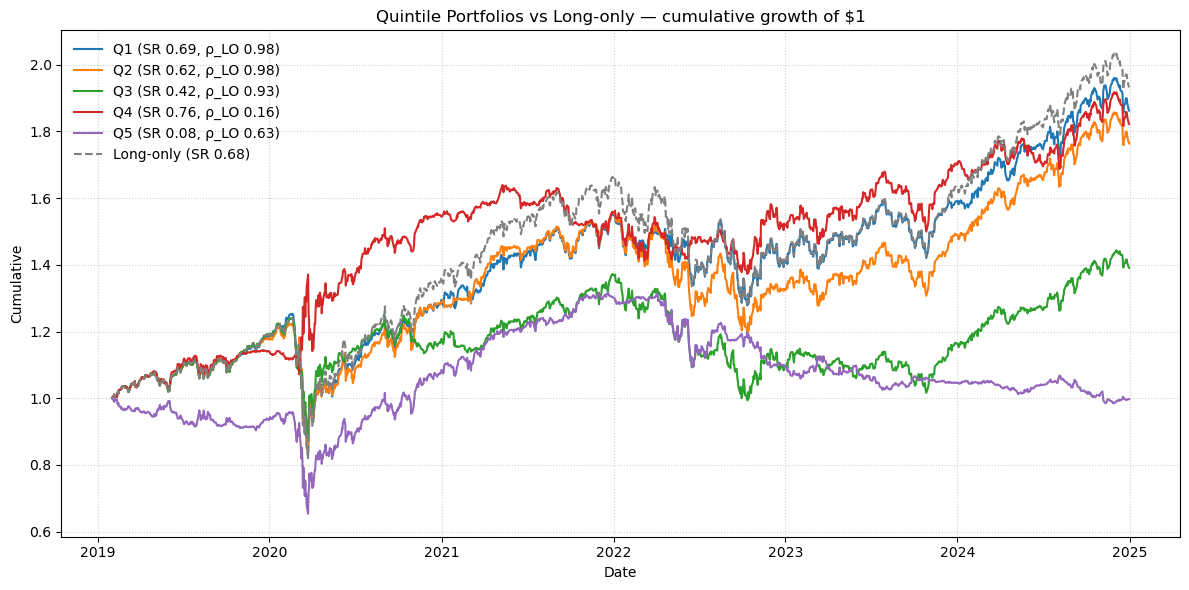

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PATH_SECTOR = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector North America.xlsx")
PATH_MACRO  = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")  # OLD macro vars (monthly, z-scored)


TRAIN_START, TRAIN_END = pd.Period('1995-01','M'), pd.Period('2018-12','M')
OOS_START,   OOS_END   = pd.Period('2019-01','M'), pd.Period('2024-12','M')


sec = pd.read_excel(PATH_SECTOR)
sec["Dates"] = pd.to_datetime(sec["Dates"], errors="coerce")
sec = sec.dropna(subset=["Dates"]).set_index("Dates").sort_index()

assets = [c for c in sec.columns if c != "Dates" and pd.api.types.is_numeric_dtype(sec[c])]
if not assets:
    raise ValueError("No numeric asset columns in sector file.")

sec_ret_daily   = sec[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all")
sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
sector_months = sec_ret_monthly.index

Z = pd.read_excel(PATH_MACRO)

# normalize the month column name
if "Month" not in Z.columns:
    for cand in ["month","MONTH","Date","Dates"]:
        if cand in Z.columns:
            Z = Z.rename(columns={cand: "Month"})
            break
if "Month" not in Z.columns:
    raise ValueError("Macro file must contain a 'Month' column (or something like Date/Dates).")

Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
Z = Z.set_index("Month").sort_index()

macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
Z = Z[macro_cols].astype(float)

Z = Z.reindex(sector_months).ffill()


F_full  = Z.copy()
F_train = F_full.loc[(F_full.index >= TRAIN_START) & (F_full.index <= TRAIN_END)].dropna(how="any")
if F_train.empty:
    raise ValueError("Training set empty after NA drop. Adjust TRAIN_* or check macro data.")

oos_stop  = min(OOS_END, sector_months.max())
months_bt = sector_months[(sector_months >= OOS_START) & (sector_months <= oos_stop)]
if len(months_bt) < 2:
    raise ValueError("No OOS months to backtest (check sector months vs OOS window).")


def rank_similar(F_full: pd.DataFrame, F_train: pd.DataFrame, cur_per: pd.Period):
    """Euclidean ranking of all training months vs current month (drop NA cols per-month)."""
    if cur_per not in F_full.index:
        return []
    x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
    if x0.empty:
        return []
    Xtr = F_train.dropna(how="any")
    common = Xtr.columns.intersection(x0.columns)
    if common.empty or Xtr.empty:
        return []
    X = Xtr[common].values.astype(float)
    x = x0.iloc[0][common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return Xtr.index[np.argsort(d)].tolist()  # closest -> farthest

def make_quintiles(ranked_months):
    """Q1=closest 20%, Q5=farthest 20%, Q2–Q4 split remaining thirds."""
    n = len(ranked_months)
    if n == 0:
        return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ranked_months[:k20]
    q5 = ranked_months[-k20:]
    mid = ranked_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}

def ann_sr(s: pd.Series):
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series):
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]  
    return df.corr().iloc[0,1] if not df.empty else np.nan

returns_by_q = {q: [] for q in range(1,6)}  # (date, value) pairs per quantile

for i in range(len(months_bt)-1):
    cur_per, nxt_per = months_bt[i], months_bt[i+1]
    ranked = rank_similar(F_full, F_train, cur_per)
    if not ranked:
        continue
    buckets = make_quintiles(ranked)

    dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt_per]
    if len(dts) == 0:
        continue
    Rm = sec_ret_daily.loc[dts, assets]

    for q in range(1,6):
        idx_sim = pd.PeriodIndex(buckets[q], freq="M") + 1
        idx_sim = sec_ret_monthly.index.intersection(idx_sim)
        if len(idx_sim) == 0:
            q_daily = pd.Series(0.0, index=dts)
        else:
            signs = {a: np.sign(sec_ret_monthly.loc[idx_sim, a].mean()) for a in assets}
            w = pd.Series(signs, index=assets, dtype=float)
            q_daily = (Rm * w).mean(axis=1)
        returns_by_q[q].extend(q_daily.items())

q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
for q in q_series:
    q_series[q].index = pd.to_datetime(q_series[q].index)

common_idx = None
for q in q_series:
    common_idx = q_series[q].index if common_idx is None else common_idx.intersection(q_series[q].index)
for q in q_series:
    q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

plt.figure(figsize=(12,6))
for q in [1,2,3,4,5]:
    sr  = ann_sr(q_series[q])
    rho = clean_corr(q_series[q], long_only)
    plt.plot(q_series[q].index, (1+q_series[q]).cumprod(),
             label=f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})")

sr_lo = ann_sr(long_only)
plt.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
         label=f"Long-only (SR {sr_lo:.2f})")

plt.title("Quintile Portfolios vs Long-only — cumulative growth of $1")
plt.xlabel("Date"); plt.ylabel("Cumulative")
plt.grid(ls=":", alpha=.6)
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\3539076248.py:113: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all")


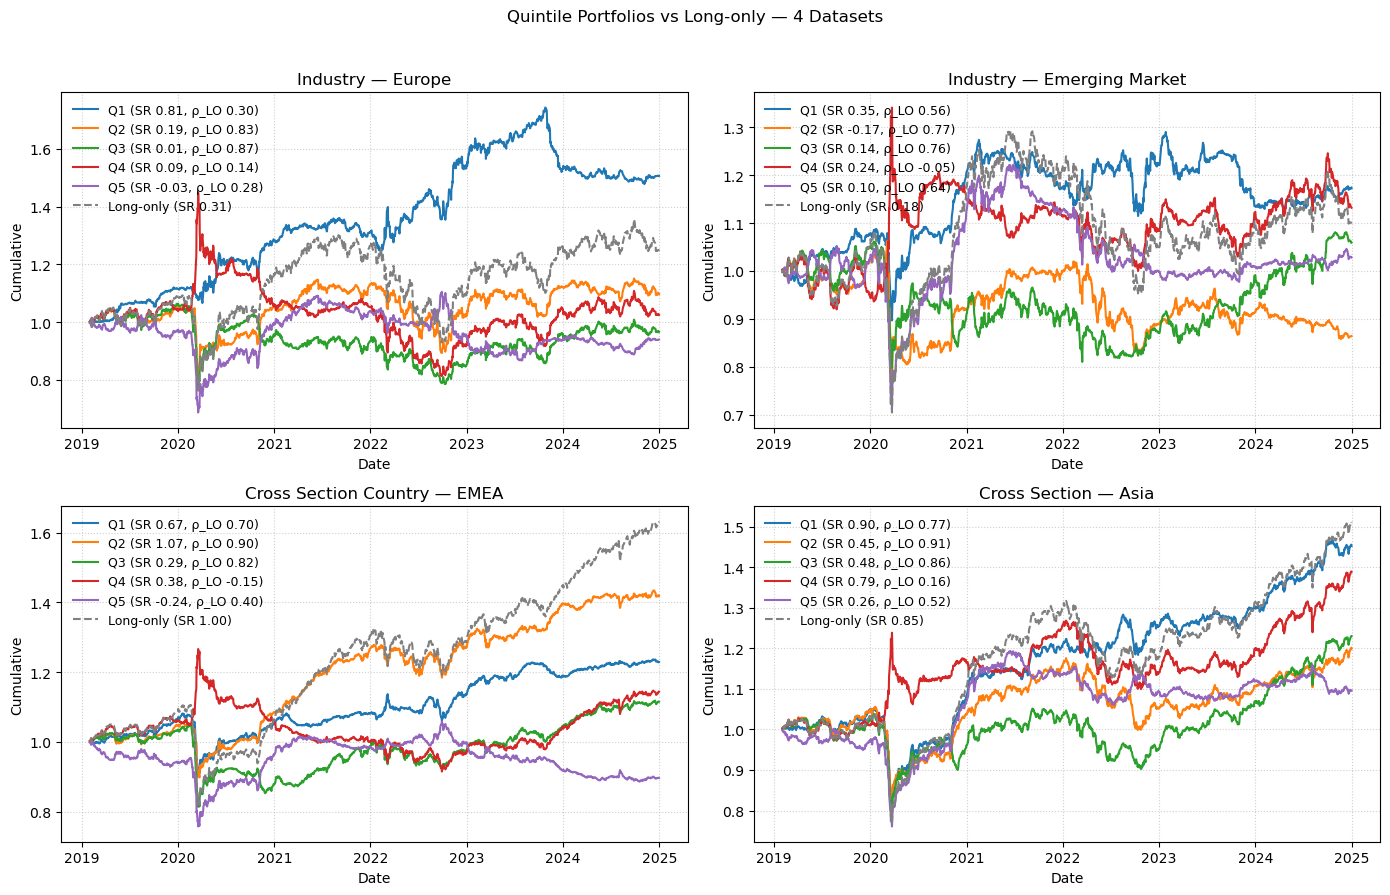

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Europe Industries.xlsx"),
     "sectors", "Industry — Europe"),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Emerging Mkt Industries.xlsx"),
     "sectors", "Industry — Emerging Market"),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\EMEA CS Country.xlsx"),
     "sectors", "Cross Section Country — EMEA"),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Asia CS Country.xlsx"),
     "factors", "Cross Section — Asia"),
]

TRAIN_START, TRAIN_END = pd.Period('2005-01','M'), pd.Period('2018-12','M')
OOS_START,   OOS_END   = pd.Period('2019-01','M'), pd.Period('2024-12','M')

def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

Z_ALL = load_macro_states(PATH_MACRO)

def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]  
    return df.corr().iloc[0,1] if not df.empty else np.nan

def rank_similar(F_full: pd.DataFrame, F_train: pd.DataFrame, cur_per: pd.Period):
    if cur_per not in F_full.index:
        return []
    x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
    if x0.empty:
        return []
    Xtr = F_train.dropna(how="any")
    common = Xtr.columns.intersection(x0.columns)
    if common.empty or Xtr.empty:
        return []
    X = Xtr[common].values.astype(float)
    x = x0.iloc[0][common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return Xtr.index[np.argsort(d)].tolist()

def make_quintiles(ranked_months):
    n = len(ranked_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ranked_months[:k20]
    q5 = ranked_months[-k20:]
    mid = ranked_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}


def load_assets(path: Path, kind: str, min_coverage: float = 1.0):

    df = pd.read_excel(path)

    if "Dates" in df.columns:
        df["Dates"] = pd.to_datetime(df["Dates"], errors="coerce")
        df = df.dropna(subset=["Dates"]).set_index("Dates").sort_index()
        assets = [c for c in df.columns if c != "Dates" and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns in {path.name}")

        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all")
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

        need = max(1, int(np.ceil(min_coverage * len(assets))))
        mask_good = sec_ret_monthly.notna().sum(axis=1) >= need
        sec_ret_monthly = sec_ret_monthly.loc[mask_good]
        sector_months   = sec_ret_monthly.index.to_period("M")

        keep = sec_ret_daily.index.to_period("M").isin(sector_months)
        sec_ret_daily = sec_ret_daily.loc[keep]

        sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
        return sec_ret_daily, sec_ret_monthly, assets, sector_months

    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    date_col = next((c for c in ["Date","Dates","DATE","date","dt"] if c in df.columns), None)
    present  = [c for c in std_cols if c in df.columns]
    if date_col and len(present) >= 5:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col).sort_index()
        df[present] = df[present].astype(float) / 100.0
        assets = [c for c in present if c != "RF"]

        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all")
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

        need = max(1, int(np.ceil(min_coverage * len(assets))))
        mask_good = sec_ret_monthly.notna().sum(axis=1) >= need
        sec_ret_monthly = sec_ret_monthly.loc[mask_good]
        sector_months   = sec_ret_monthly.index.to_period("M")

        keep = sec_ret_daily.index.to_period("M").isin(sector_months)
        sec_ret_daily = sec_ret_daily.loc[keep]

        sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
        return sec_ret_daily, sec_ret_monthly, assets, sector_months

    raise ValueError(f"Could not figure out schema for {path.name} — expected 'Dates' or FF6 columns.")



def build_quintile_series(path: Path, kind: str):
    # 1) Load assets & returns
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets(path, kind)

    Z = Z_ALL.reindex(sector_months).ffill()
    F_full  = Z.copy()
    F_train = F_full.loc[(F_full.index >= TRAIN_START) & (F_full.index <= TRAIN_END)].dropna(how="any")
    if F_train.empty:
        raise ValueError(f"Training set empty for {path.name} after NA drop. Check dates or macro coverage.")

    oos_stop  = min(OOS_END, sector_months.max())
    months_bt = sector_months[(sector_months >= OOS_START) & (sector_months <= oos_stop)]
    if len(months_bt) < 2:
        raise ValueError(f"No OOS months for {path.name}. Got {sector_months.min()}..{sector_months.max()} vs requested {OOS_START}..{OOS_END}.")

    returns_by_q = {q: [] for q in range(1,6)}  # (date, val)

    for i in range(len(months_bt)-1):
        cur_per, nxt_per = months_bt[i], months_bt[i+1]
        ranked = rank_similar(F_full, F_train, cur_per)
        if not ranked:
            continue
        buckets = make_quintiles(ranked)

        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == nxt_per]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in range(1,6):
            idx_sim = pd.PeriodIndex(buckets[q], freq="M") + 1  # next month after similar months
            idx_sim = sec_ret_monthly.index.intersection(idx_sim)
            if len(idx_sim) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                signs = {a: np.sign(sec_ret_monthly.loc[idx_sim, a].mean()) for a in assets}
                w = pd.Series(signs, index=assets, dtype=float)
                q_daily = (Rm * w).mean(axis=1)
            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        common_idx = q_series[q].index if common_idx is None else common_idx.intersection(q_series[q].index)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title) in zip(axes, DATASETS):
    q_series, long_only = build_quintile_series(path, kind)

    for q in [1,2,3,4,5]:
        sr  = ann_sr(q_series[q])
        rho = clean_corr(q_series[q], long_only)
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(),
                label=f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})")

    sr_lo = ann_sr(long_only)
    ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
            label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(title)
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle("Quintile Portfolios vs Long-only — 4 Datasets", y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\2711611876.py:158: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


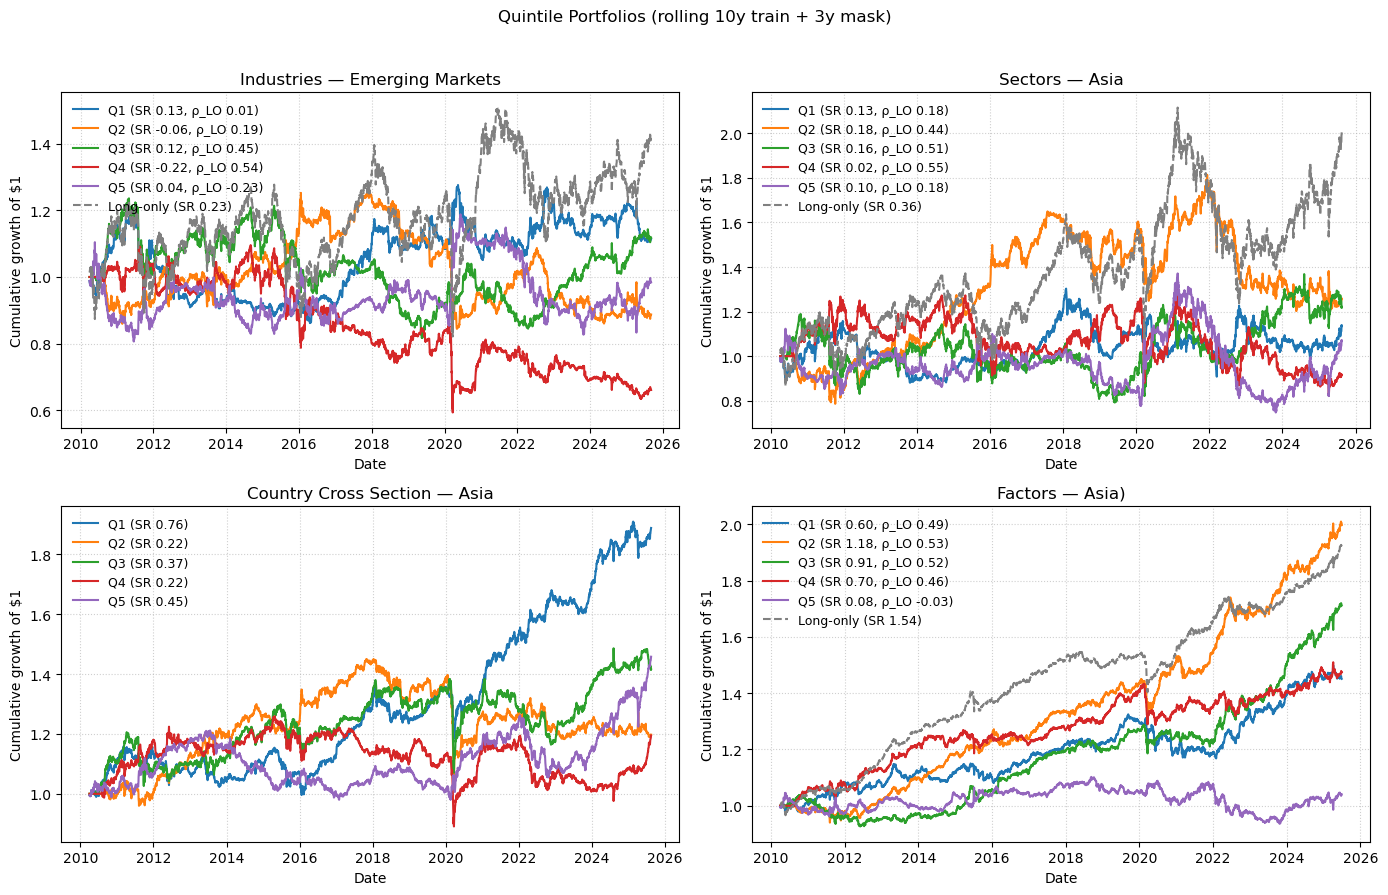

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Asia\state_z_asia.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Emerging Mkt Industries.xlsx"),
     "auto", "Industries — Emerging Markets", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector Asia.xlsx"),
     "auto", "Sectors — Asia", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Asia CS Country.xlsx"),
     "auto", "Country Cross Section — Asia", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Asia\FF6_Asian_daily_cleaned.xlsx"),
     "auto", "Factors — Asia)", True),
]

TRAIN_YEARS = 10
MASK_YEARS  = 3

MIN_COVERAGE = 1.0   

def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)] 
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ranked_months):
    n = len(ranked_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ranked_months[:k20]
    q5 = ranked_months[-k20:]
    mid = ranked_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}

def rank_similar(F_full: pd.DataFrame, F_train: pd.DataFrame, cur_per: pd.Period):
    if cur_per not in F_full.index:
        return []
    x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
    if x0.empty:
        return []
    Xtr = F_train.dropna(how="any")
    common = Xtr.columns.intersection(x0.columns)
    if common.empty or Xtr.empty:
        return []
    X = Xtr[common].values.astype(float)
    x = x0.iloc[0][common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return Xtr.index[np.argsort(d)].tolist()


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    """Robust date parsing for either 'Dates' or 'Date' style columns.
    Handles datetime, 'YYYY-MM-DD', and 8-digit YYYYMMDD (e.g., 19901101)."""
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]

    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")

    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt


def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]  # guard against hidden spaces
    std_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:  
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)

        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf, -np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    else:
        assets = [c for c in df.columns if c not in ["Dates", "Date", "DATE", "date", "dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(
                f"Could not infer schema for {path.name} — need FF6 cols or numeric columns beside the date."
            )
        sec_ret_daily   = df[assets].pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months



def build_quintile_series_rolling_masked(path: Path,
                                         kind: str = "auto",
                                         train_years: int = TRAIN_YEARS,
                                         mask_years: int  = MASK_YEARS,
                                         min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    first_eval = (min_m.asfreq("M") + (train_years + mask_years) * 12)
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}  

    for m in months_bt:
        tr_end   = (m - mask_years)  
        tr_start = tr_end - (train_years * 12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.empty:  
            continue

        if m not in Z.index:
            continue
        F_full = Z  

        ranked = rank_similar(F_full, F_train, m)
        if not ranked:
            continue
        buckets = make_quintiles(ranked)

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            months_sim = buckets[q]
            if len(months_sim) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                idx_sim_next = pd.PeriodIndex(months_sim, freq="M") + 1
                idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
                if len(idx_sim_next) == 0:
                    q_daily = pd.Series(0.0, index=dts)
                else:
                    signs = {a: np.sign(sec_ret_monthly.loc[idx_sim_next, a].mean()) for a in assets}
                    w = pd.Series(signs, index=assets, dtype=float)
                    q_daily = (Rm * w).mean(axis=1)
            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only = build_quintile_series_rolling_masked(path, kind, TRAIN_YEARS, MASK_YEARS, MIN_COVERAGE)

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(title)
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle(f"Quintile Portfolios (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask)", y=0.99)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


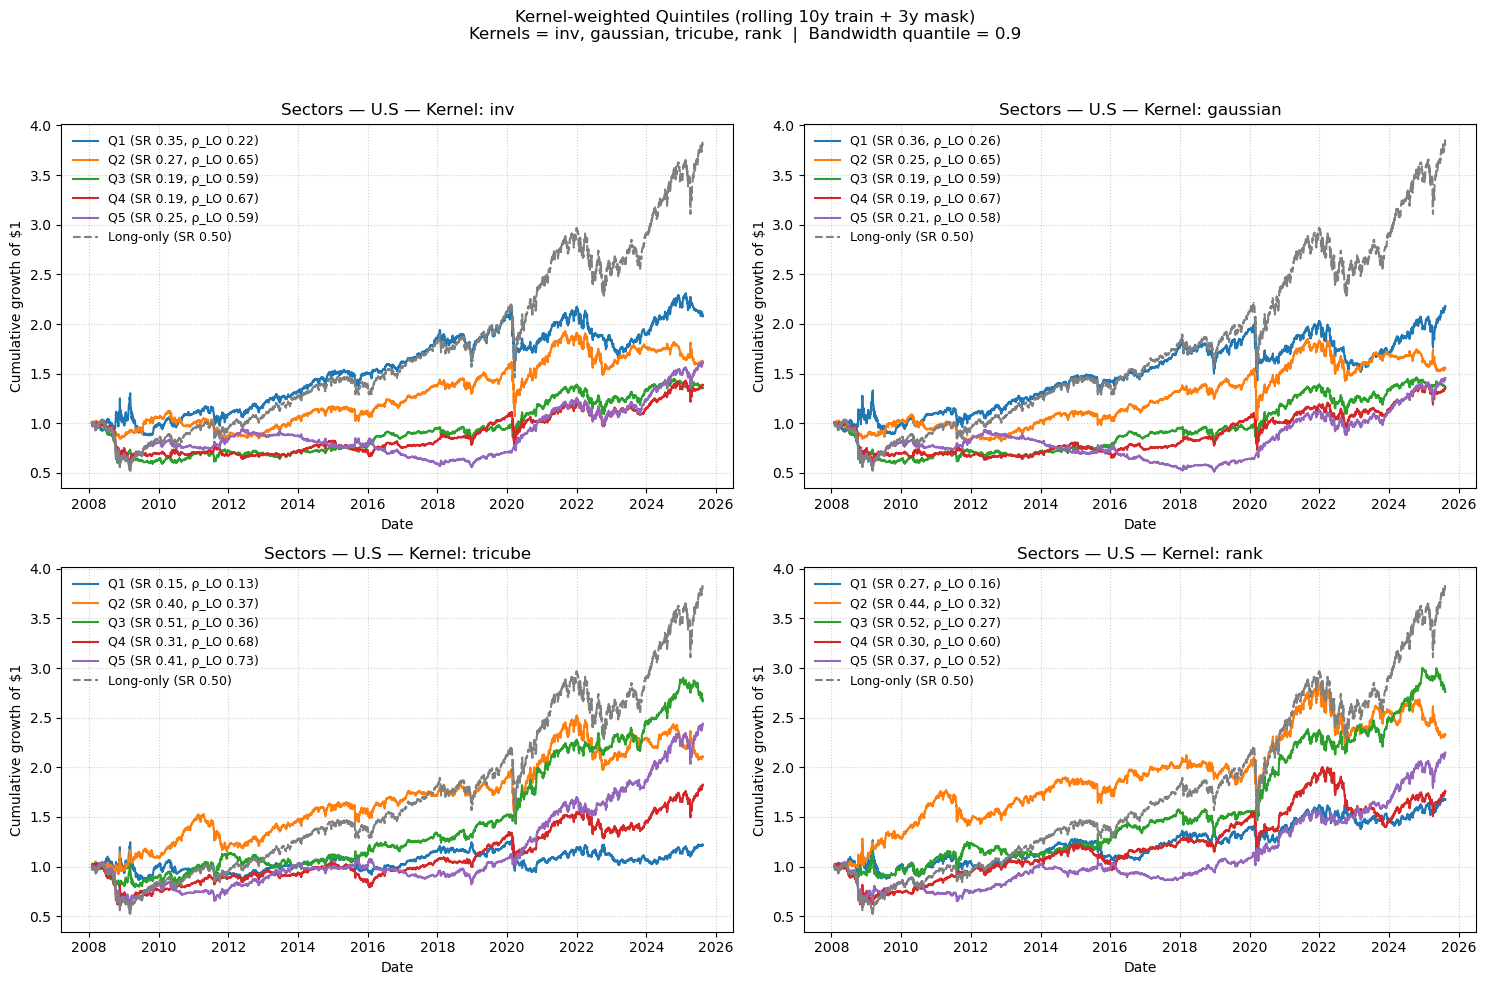

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector North America.xlsx"),
     "auto", "Sectors — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Developped Countries Industry.xlsx"),
     "auto", "Industries — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Americas CS Country.xlsx"),
     "auto", "Country Cross Section — America", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"),
     "auto", "Factors — U.S.", True),
]

TRAIN_YEARS = 10
MASK_YEARS  = 3
MIN_COVERAGE = 1.0 

KERNELS = ["inv", "gaussian", "tricube", "rank"]
BW_QUANTILE = 0.90  

def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ranked_months):
    n = len(ranked_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ranked_months[:k20]
    q5 = ranked_months[-k20:]
    mid = ranked_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}

def _distance_weights(d: pd.Series,
                      kernel: str = "inv",
                      h: float | None = None,
                      bw_quantile: float = 0.9,
                      eps: float = 1e-12) -> pd.Series:
    """Convert distances (indexed by months) to normalized weights."""
    d = pd.to_numeric(d, errors="coerce").astype(float)
    if h is None and kernel in ("gaussian", "tricube"):
        finite = d[np.isfinite(d)]
        if len(finite) == 0:
            h = 1.0
        else:
            h = np.quantile(finite, bw_quantile)
            h = max(h, eps)

    if kernel == "inv":
        w = 1.0 / (d.values + eps)

    elif kernel == "gaussian":
        u = d.values / h
        w = np.exp(-0.5 * u * u)

    elif kernel == "tricube":
        u = np.clip(d.values / h, 0, 1)
        w = (1 - u**3)**3

    elif kernel == "rank":
        ranks = np.arange(1, len(d) + 1, dtype=float)
        w = 1.0 / ranks

    else:
        raise ValueError("kernel must be one of {'inv','gaussian','tricube','rank'}")

    w = np.clip(w, 0, np.inf)
    s = w.sum()
    if not np.isfinite(s) or s <= 0:
        w = np.ones_like(w) / max(len(w), 1)
    else:
        w = w / s
    return pd.Series(w, index=d.index)

def _weighted_mean_ignore_nans(x: pd.Series, w: pd.Series) -> float:
    """Weighted mean of x using weights w, after aligning, dropping NaNs, and renormalizing."""
    xy = pd.concat([x, w], axis=1).dropna(subset=[x.name])
    if xy.empty:
        return np.nan
    w2 = xy[w.name]
    s = w2.sum()
    if s <= 0 or not np.isfinite(s):
        return np.nan
    return (xy[x.name] * w2 / s).sum()

def rank_with_dist(F_full: pd.DataFrame, F_train: pd.DataFrame, cur_per: pd.Period) -> pd.Series:
    """Return distances (Series) from each training month to current month (smaller = closer)."""
    if cur_per not in F_full.index:
        return pd.Series(dtype=float)
    x0 = F_full.loc[[cur_per]].dropna(axis=1, how="any")
    if x0.empty:
        return pd.Series(dtype=float)
    Xtr = F_train.dropna(how="any")
    common = Xtr.columns.intersection(x0.columns)
    if common.empty or Xtr.empty:
        return pd.Series(dtype=float)
    X = Xtr[common].values.astype(float)
    x = x0.iloc[0][common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return pd.Series(d, index=Xtr.index).sort_values()


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months

def build_quintile_series_rolling_masked_kernel(path: Path,
                                                kernel: str = "inv",
                                                bw_quantile: float = BW_QUANTILE,
                                                train_years: int = TRAIN_YEARS,
                                                mask_years: int  = MASK_YEARS,
                                                min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    first_eval = (min_m.asfreq("M") + (train_years + mask_years) * 12)
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}  

    for m in months_bt:
        tr_end   = (m - mask_years)
        tr_start = tr_end - (train_years * 12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.empty or (m not in Z.index):
            continue

        d = rank_with_dist(Z, F_train, m)   
        if d.empty:
            continue

        buckets = make_quintiles(list(d.index))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        for q in [1,2,3,4,5]:
            q_months = buckets[q]
            if len(q_months) == 0:
                q_daily = pd.Series(0.0, index=dts)
            else:
                d_q = d.loc[q_months]
                w_q = _distance_weights(d_q, kernel=kernel, bw_quantile=bw_quantile)
                idx_sim_next = (pd.PeriodIndex(q_months, freq="M") + 1)
                idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)

                if len(idx_sim_next) == 0:
                    q_daily = pd.Series(0.0, index=dts)
                else:
                    
                    train_months_for_next = (idx_sim_next - 1).astype('period[M]')
                    w_align = w_q.reindex(train_months_for_next)
                    signs = {}
                    for a in assets:
                        r = sec_ret_monthly.loc[idx_sim_next, a]
                        r.name = "r" 
                        w_align.name = "w"
                        mu = _weighted_mean_ignore_nans(r, w_align)
                        signs[a] = np.sign(mu) if np.isfinite(mu) else 0.0
                    w_assets = pd.Series(signs, index=assets, dtype=float)
                    q_daily = (Rm * w_assets).mean(axis=1)

            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    return q_series, long_only


fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, kernel in zip(axes, KERNELS):

    path, kind, title, show_lo = DATASETS[0]

    q_series, long_only = build_quintile_series_rolling_masked_kernel(
        path=path,
        kernel=kernel,
        bw_quantile=BW_QUANTILE,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Kernel: {kernel}")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle(f"Kernel-weighted Quintiles (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask)\n"
             f"Kernels = {', '.join(KERNELS)}  |  Bandwidth quantile = {BW_QUANTILE}",
             y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


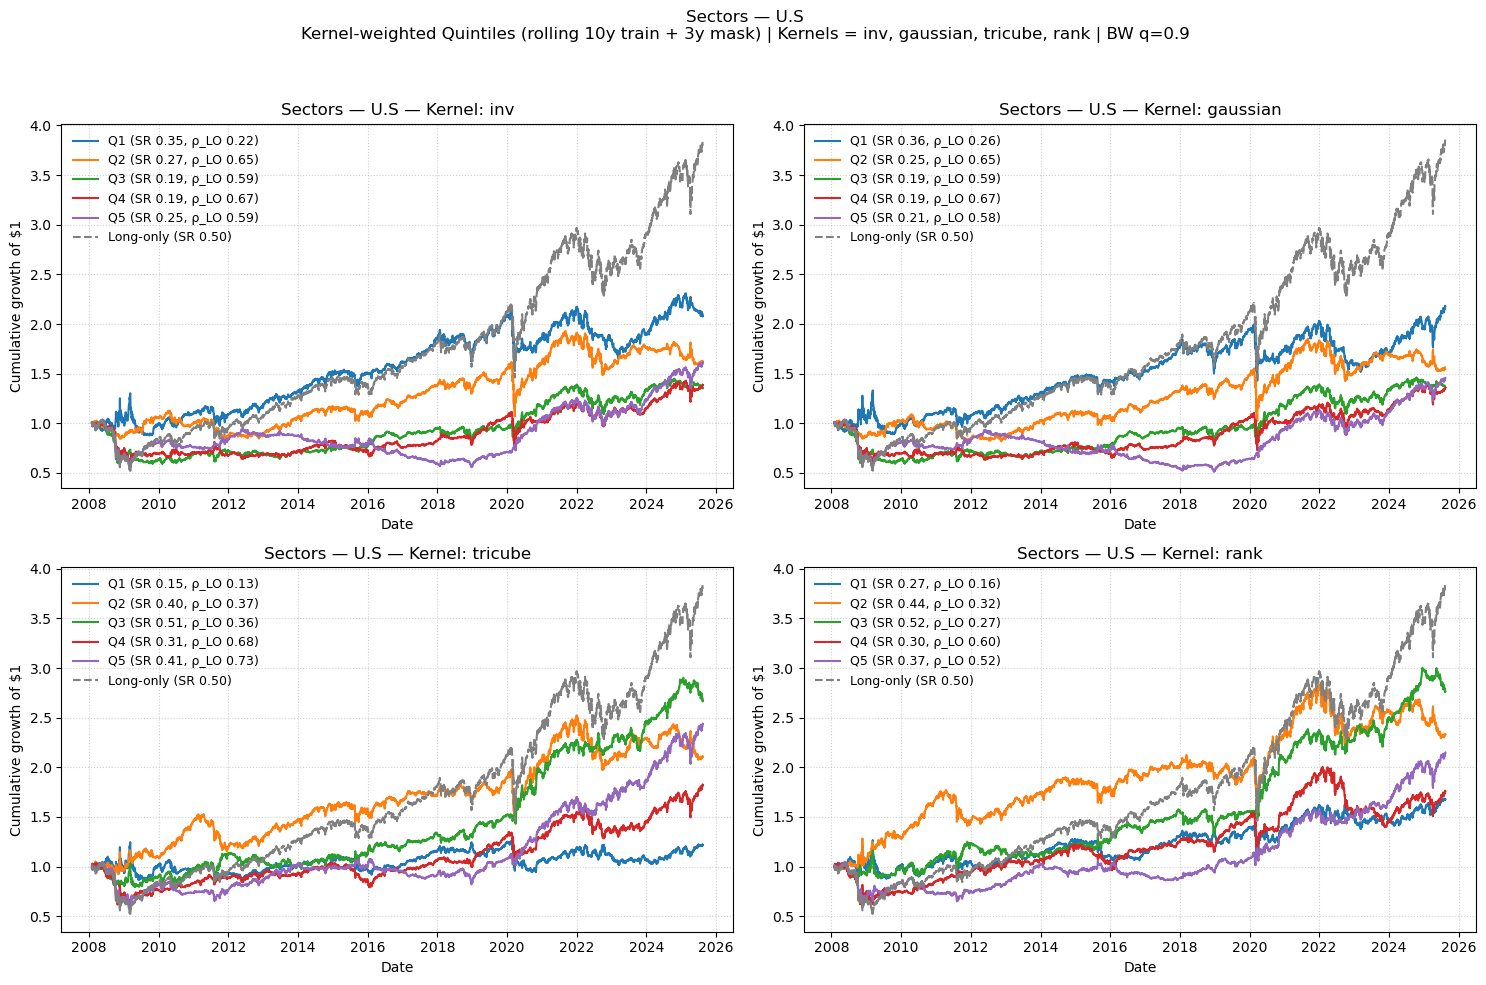

C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\4025055782.py:198: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\4025055782.py:198: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
C:\Users\kelvi\AppData\Local\Temp\ipykernel_57876\4025055782.py:198: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is depre

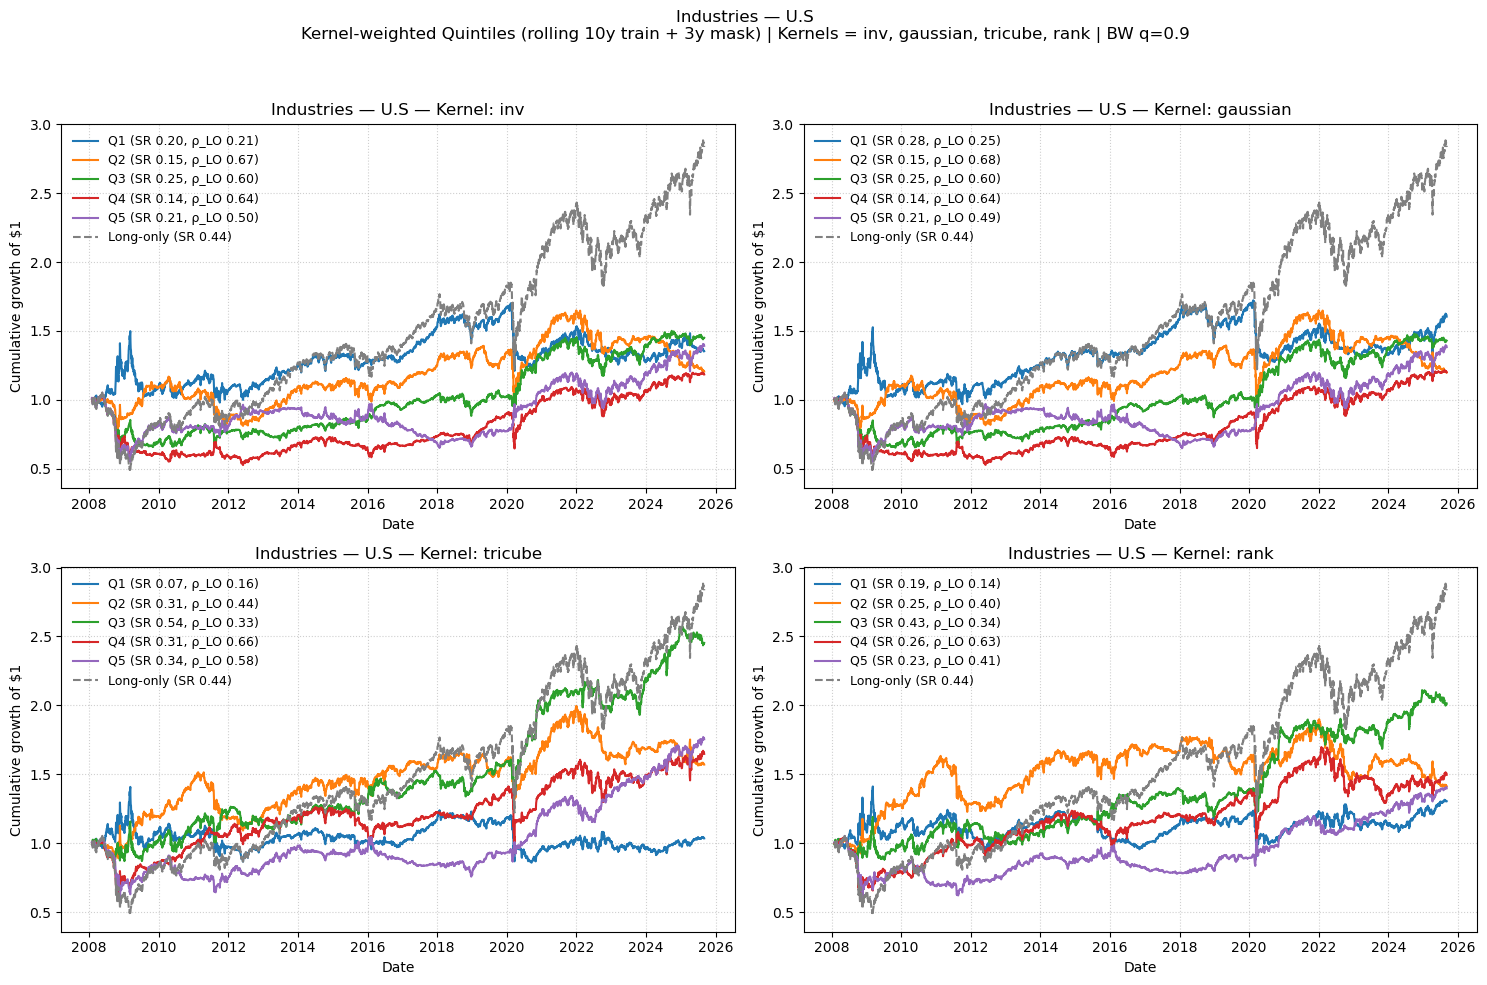

KeyboardInterrupt: 

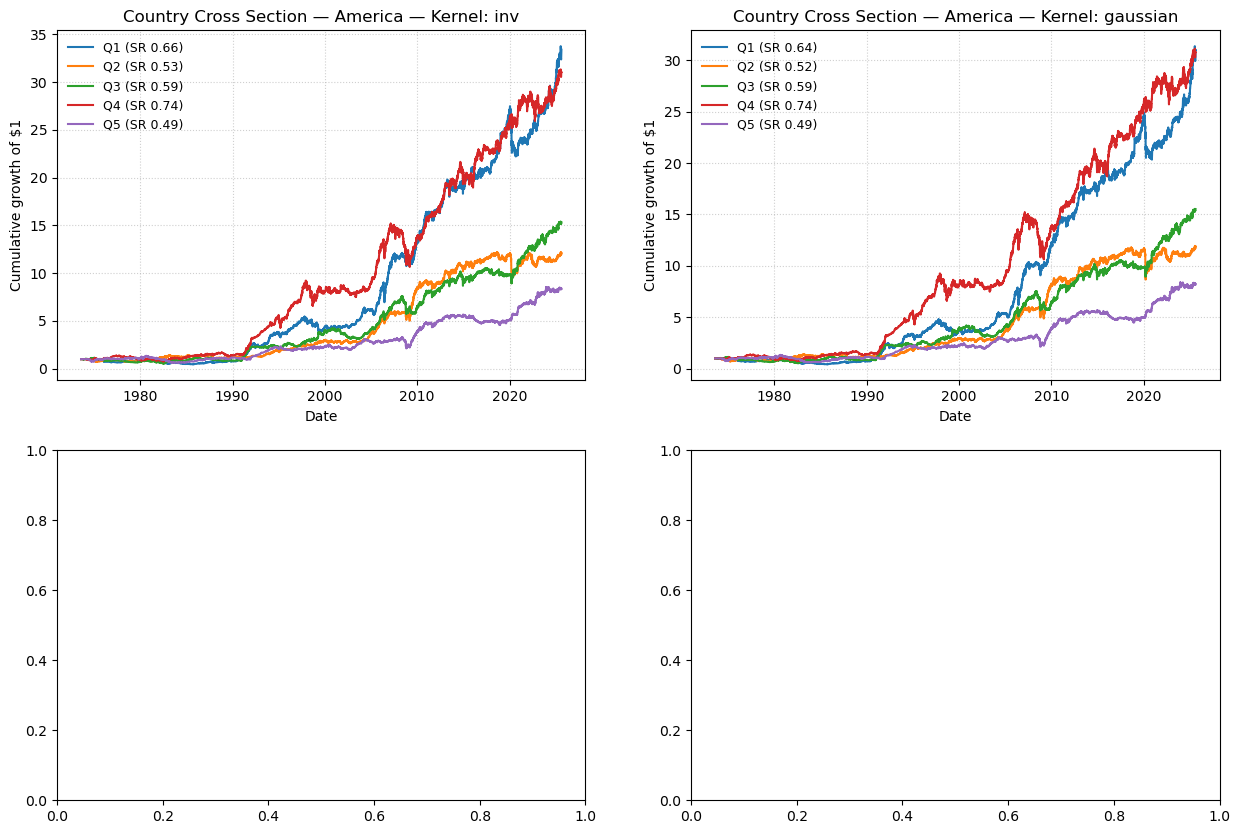

In [67]:

for path, kind, title, show_lo in DATASETS:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
    axes = axes.ravel()

    for ax, kernel in zip(axes, KERNELS):
        q_series, long_only = build_quintile_series_rolling_masked_kernel(
            path=path,
            kernel=kernel,
            bw_quantile=BW_QUANTILE,
            train_years=TRAIN_YEARS,
            mask_years=MASK_YEARS,
            min_coverage=MIN_COVERAGE
        )

        for q in [1,2,3,4,5]:
            sr = ann_sr(q_series[q])
            if show_lo:
                rho = clean_corr(q_series[q], long_only)
                lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
            else:
                lbl = f"Q{q} (SR {sr:.2f})"
            ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

        if show_lo:
            sr_lo = ann_sr(long_only)
            ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                    label=f"Long-only (SR {sr_lo:.2f})")

        ax.set_title(f"{title} — Kernel: {kernel}")
        ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
        ax.grid(ls=":", alpha=.6)
        ax.legend(frameon=False, loc="upper left", fontsize=9)

    plt.suptitle(
        f"{title}\nKernel-weighted Quintiles (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask) "
        f"| Kernels = {', '.join(KERNELS)} | BW q={BW_QUANTILE}",
        y=0.98
    )
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
